<a href="https://colab.research.google.com/github/adisu-moga/Machine-Learning-Regression-Models-using-House-Price-Dataset/blob/main/regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Housing Price.csv to Housing Price.csv


In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("Housing Price.csv")

# Display the first 5 rows
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Check data types and missing values
df.info()

# Basic statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
# Convert categorical columns to dummy variables
df = pd.get_dummies(df, drop_first=True)

# Check the updated dataset
df.head()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [ ]:
# Assuming 'price' is the column to predict
X = df.drop("price", axis=1)
y = df["price"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict
y_pred = lin_reg.predict(X_test)

# Evaluate
print("Linear Regression R2:", r2_score(y_test, y_pred))
# Calculate MSE and then take its square root to get RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
print("Linear Regression RMSE:", rmse)

Linear Regression R2: 0.6529242642153184
Linear Regression RMSE: 1324506.9600914386


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Transform features to polynomial features (degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Predict
y_pred_poly = poly_reg.predict(X_test_poly)

# Evaluate
print("Polynomial Regression R2:", r2_score(y_test, y_pred_poly))
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = mse_poly**0.5
print("Polynomial Regression RMSE:", rmse_poly)

Polynomial Regression R2: 0.6208412814380686
Polynomial Regression RMSE: 1384371.473807165


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Regression R2:", r2_score(y_test, y_pred_knn))
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = mse_knn**0.5
print("KNN Regression RMSE:", rmse_knn)

KNN Regression R2: 0.36417150272211063
KNN Regression RMSE: 1792718.5512869665


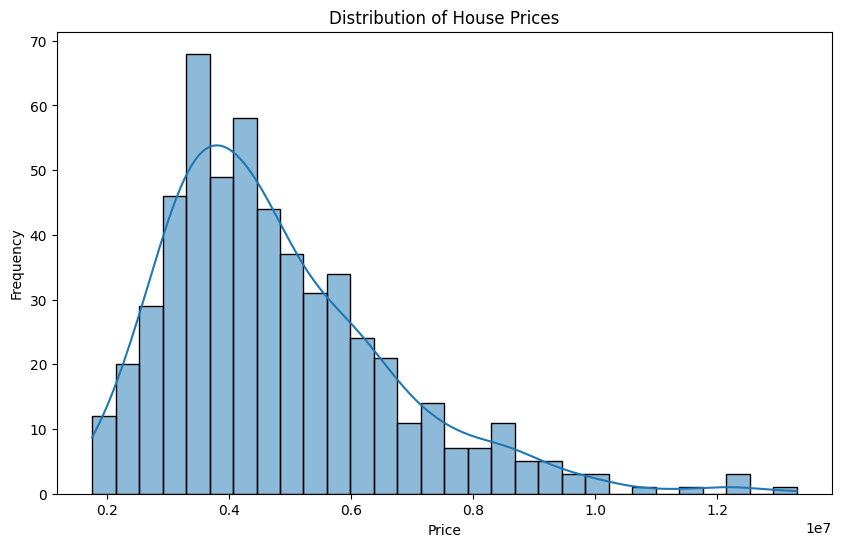

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

NameError: name 'df' is not defined

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Regression R2:", r2_score(y_test, y_pred_dt))
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt**0.5
print("Decision Tree Regression RMSE:", rmse_dt)

Decision Tree Regression R2: 0.4771459275854347
Decision Tree Regression RMSE: 1625669.904259373


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save the DataFrame to Drive
df.to_csv('/content/drive/MyDrive/Housing_Price_processed.csv', index=False)

MessageError: Error: credential propagation was unsuccessful

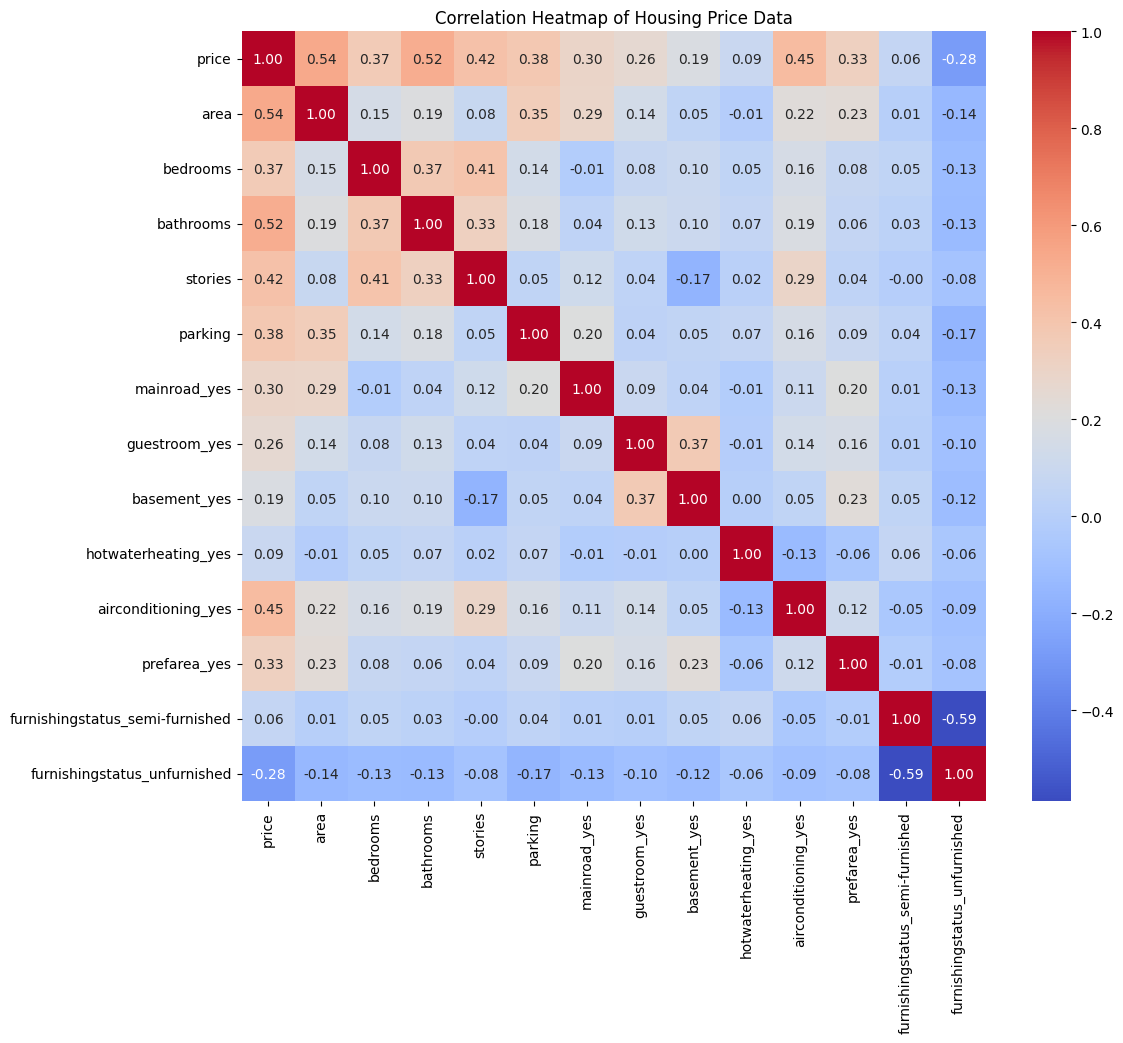

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Housing Price Data')
plt.show()

# Task
Please run cells `hIV3S4DH-7jf` and `0TWILStR_M3K` to define and process the `df` DataFrame, then execute cell `06f6fc84` to download the 'Housing_Price_processed.csv' file.

## Ensure DF is Defined

### Subtask:
Run the necessary cells to define and preprocess the 'df' DataFrame.


**Reasoning**:
The first instruction is to execute the cell with ID `hIV3S4DH-7jf` to load the data into a DataFrame named `df`.



In [4]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("Housing Price.csv")

# Display the first 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**Reasoning**:
The next instruction is to execute the cell with ID `0TWILStR_M3K` to convert categorical columns in `df` into dummy variables. This step is essential for preparing the data for machine learning models that require numerical inputs.



In [5]:
df = pd.get_dummies(df, drop_first=True)

# Check the updated dataset
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


**Reasoning**:
The next instruction is to execute cell `06f6fc84` to download the 'Housing_Price_processed.csv' file. The `df` DataFrame, which was causing a `NameError` previously, is now defined and processed after executing the preceding steps.



In [6]:
from google.colab import files

# Ensure 'df' DataFrame is defined from previous steps
# Save the DataFrame to a CSV file in the Colab environment
df.to_csv('Housing_Price_processed.csv', index=False)

# Download the file to your local computer
files.download('Housing_Price_processed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary:

### Data Analysis Key Findings
*   The initial DataFrame, `df`, was successfully loaded from 'Housing Price.csv' and contained columns relevant to housing prices, area, bedrooms, and various categorical features.
*   Categorical variables within the `df` were successfully transformed into numerical dummy variables using `pd.get_dummies` with `drop_first=True`, preparing the dataset for quantitative analysis.
*   The final processed DataFrame, 'Housing\_Price\_processed.csv', was saved and made available for download, confirming the completion of all specified processing steps.

### Insights or Next Steps
*   The preprocessing step, particularly the creation of dummy variables with `drop_first=True`, effectively handles categorical data and mitigates potential multicollinearity issues for subsequent machine learning model training.
*   The processed 'Housing\_Price\_processed.csv' DataFrame is now ready for further analytical tasks, such as exploratory data analysis, feature engineering, or training predictive models for housing price prediction.
